In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import jax.numpy as jnp
from joblib import Parallel, delayed
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# Ensure your custom class is in the same directory or installed
from bilinear_lasso import bilinear_lasso

# --- Configuration ---
DATA_DIR = "/Users/xue6bq/Desktop/Aiying/Data"
OUTPUT_DIR = "cv_results_parallel"
P, N_SUBJECTS = 264, 787
LAMBDA_GRID = [0.1,0.5,1,3,5,7,9]
N_SPLITS, N_JOBS = 5, 3
MAX_ITER, STEP_SIZE, TOL = 6000, 1e-6, 1e-5

os.makedirs(OUTPUT_DIR, exist_ok=True)

def load_fmri_data(data_dir, p=264, n_subjects=None):
    z_rs = np.load(os.path.join(data_dir, "z_rs_raw.npy")).reshape((-1, p, p))
    z_emo = np.load(os.path.join(data_dir, "z_emo_raw.npy")).reshape((-1, p, p))
    y = np.load(os.path.join(data_dir, "y.npy"))
    
    # Transpose to p x p x n (nodes, nodes, subjects)
    X1 = jnp.array(np.transpose(z_rs, (1, 2, 0)))
    X2 = jnp.array(np.transpose(z_emo, (1, 2, 0)))
    y = jnp.array(y)
    
    print(f"Loaded Data: X1={X1.shape}, X2={X2.shape}, y={y.shape}")
    return X1, X2, y

def predict_bilinear(X1, X2, beta1, beta2):
    """Computes b.T * X * b across all subjects."""
    b1 = np.array(beta1).flatten()
    b2 = np.array(beta2).flatten()
    X1_np, X2_np = np.array(X1), np.array(X2)
    
    return (np.einsum("i,ijk,j->k", b1, X1_np, b1) + 
            np.einsum("i,ijk,j->k", b2, X2_np, b2))

def evaluate_prediction(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mse = np.mean((y_true - y_pred) ** 2)
    var_y = np.var(y_true)
    r2 = 1 - mse / var_y if var_y > 1e-9 else np.nan
    corr = np.corrcoef(y_true, y_pred)[0, 1] if np.std(y_pred) > 1e-9 else 0
    return {"mse": float(mse), "r2": float(r2), "corr": float(corr)}

In [2]:
def calculate_ebic(mse, n_features, n_samples, total_p, gamma=0.5):
    """
    Computes BIC and EBIC.
    BIC = n*log(MSE) + k*log(n)
    EBIC = BIC + 2*gamma*k*log(p)
    """
    if mse <= 1e-12:  # Prevent log(0)
        return -np.inf, -np.inf
    
    k = n_features
    n = n_samples
    
    bic = n * np.log(mse) + k * np.log(n)
    # EBIC adds a penalty for the search space size (total_p)
    ebic = bic + 2 * gamma * k * np.log(total_p)
    
    return bic, ebic

def run_one_cv_fold(X1, X2, y, train_idx, val_idx, lam, p, max_iter, step_size, tol):
    # 1. Split Data
    X1_tr, X1_val = X1[:, :, train_idx], X1[:, :, val_idx]
    X2_tr, X2_val = X2[:, :, train_idx], X2[:, :, val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # 2. Centering (Subtract mean, maintain scale/STD)
    y_m = y_tr.mean()
    y_tr_c, y_val_c = y_tr - y_m, y_val - y_m
    
    X1_m, X2_m = X1_tr.mean(axis=2, keepdims=True), X2_tr.mean(axis=2, keepdims=True)
    X1_tr_c, X1_val_c = X1_tr - X1_m, X1_val - X1_m
    X2_tr_c, X2_val_c = X2_tr - X2_m, X2_val - X2_m

    # 3. Fit Model on Training Set
    model = bilinear_lasso(X1_tr_c, X2_tr_c, y_tr_c, lam, lam)
    model.initialize_beta(jnp.zeros((p, 1)), jnp.zeros((p, 1)))
    model.fit(num_candidates=1, max_iter=max_iter, step_size=step_size, tol=tol)

    # 4. Extract Support
    # Using a small epsilon to catch non-zero coefficients
    supp1 = np.where(np.abs(np.array(model.beta1).flatten()) > 0.1)[0]
    supp2 = np.where(np.abs(np.array(model.beta2).flatten()) > 0.1)[0]
    n_features = len(supp1) + len(supp2)

    # 5. Training Evaluation (For BIC/EBIC)
    y_pred_tr = predict_bilinear(X1_tr_c, X2_tr_c, model.beta1, model.beta2)
    tr_mse = np.mean((np.array(y_tr_c) - y_pred_tr)**2)
    
    # Calculate BIC and EBIC (p*2 because we have two beta vectors of size p)
    bic, ebic = calculate_ebic(tr_mse, n_features, len(train_idx), p * 2)

    # 6. Validation Evaluation (For Prediction Performance)
    y_pred_val = predict_bilinear(X1_val_c, X2_val_c, model.beta1, model.beta2)
    metrics = evaluate_prediction(y_val_c, y_pred_val)
    
    return {
        "lambda": lam,
        "val_mse": metrics["mse"],
        "val_r2": metrics["r2"],
        "val_corr": metrics["corr"],
        "tr_mse": float(tr_mse),
        "bic": float(bic),
        "ebic": float(ebic),
        "supp1": supp1,
        "supp2": supp2,
        "n_features": n_features
    }

def run_one_lambda_cv(lam, X1, X2, y):
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=2026)
    
    # Run the folds
    folds = [run_one_cv_fold(X1, X2, y, tr, val, lam, P, MAX_ITER, STEP_SIZE, TOL) 
             for tr, val in kf.split(np.arange(y.shape[0]))]
    
    # Metrics extraction
    mse_list = [f["val_mse"] for f in folds]
    mean_mse = np.mean(mse_list)
    sd_mse = np.std(mse_list)
    
    # Aggregating Information Criteria
    mean_bic = np.mean([f["bic"] for f in folds])
    mean_ebic = np.mean([f["ebic"] for f in folds])
    
    # Stability: Lower is more consistent across folds
    cv_stability = sd_mse / mean_mse if mean_mse > 1e-9 else np.nan
    
    return {
        "lambda": lam,
        "mean_r2": np.mean([f["val_r2"] for f in folds]),
        "mean_mse": mean_mse,
        "sd_mse": sd_mse,
        "mean_bic": mean_bic,
        "mean_ebic": mean_ebic,
        "cv_stability": cv_stability, 
        "mean_features": np.mean([f["n_features"] for f in folds]),
        "folds": folds
    }

In [3]:
X1, X2, y = load_fmri_data(DATA_DIR, P, N_SUBJECTS)

# 1. Run the parallel CV
results = Parallel(n_jobs=N_JOBS)(
    delayed(run_one_lambda_cv)(l, X1, X2, y) for l in LAMBDA_GRID
)

# 2. Organize into a comprehensive summary table
summary_data = []
for r in results:
    summary_data.append({
        "lambda": r["lambda"],
        "Test R2": r["mean_r2"],
        "Avg Features": r["mean_features"],
        "EBIC": r["mean_ebic"],        # Added for model selection
        "BIC": r["mean_bic"],          # Added for reference
        "Stability": r["cv_stability"], # Lower is more reliable
        "MSE Mean": r["mean_mse"]
    })

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data)

# Sort by EBIC (often the most robust metric for fMRI feature selection)
summary_df = summary_df.sort_values("EBIC")

print("\n--- Model Evaluation Summary (Sorted by EBIC) ---")
display(summary_df)

Loaded Data: X1=(264, 264, 787), X2=(264, 264, 787), y=(787,)
0 th try
initialized loss: 391.3551940917969


  0%|          | 11/6000 [00:01<08:39, 11.52it/s] 

0 th try
initialized loss: 399.09136962890625


  1%|          | 31/6000 [00:03<09:25, 10.55it/s] 

0 th try
initialized loss: 393.5017395019531


...

 52%|█████▏    | 3112/6000 [04:00<03:42, 12.96it/s]

Job took:  478.76562786102295
Final loss: 378.0240478515625
Final loss: 378.0240478515625


100%|██████████| 6000/6000 [06:45<00:00, 14.78it/s]


Job took:  405.97455191612244
Final loss: 352.45538330078125
Final loss: 352.45538330078125

--- Model Evaluation Summary (Sorted by EBIC) ---


,lambda,Test R2,Avg Features,EBIC,BIC,Stability,MSE Mean
5,7.0,-0.006987,0.0,3760.003076,3760.003076,0.033826,393.409192
6,9.0,-0.006987,0.0,3760.003076,3760.003076,0.033826,393.409192
4,5.0,0.031808,12.8,3845.544339,3765.299906,0.044235,378.127698
3,3.0,0.014673,35.0,4018.222665,3798.804295,0.044227,384.863159
2,1.0,-0.213296,178.6,5428.246921,4308.586325,0.111885,474.608435
1,0.5,-0.406603,291.6,6618.868285,4790.799808,0.129124,549.016907
0,0.1,-0.963680,435.2,8328.353692,5600.042989,0.076575,767.330908


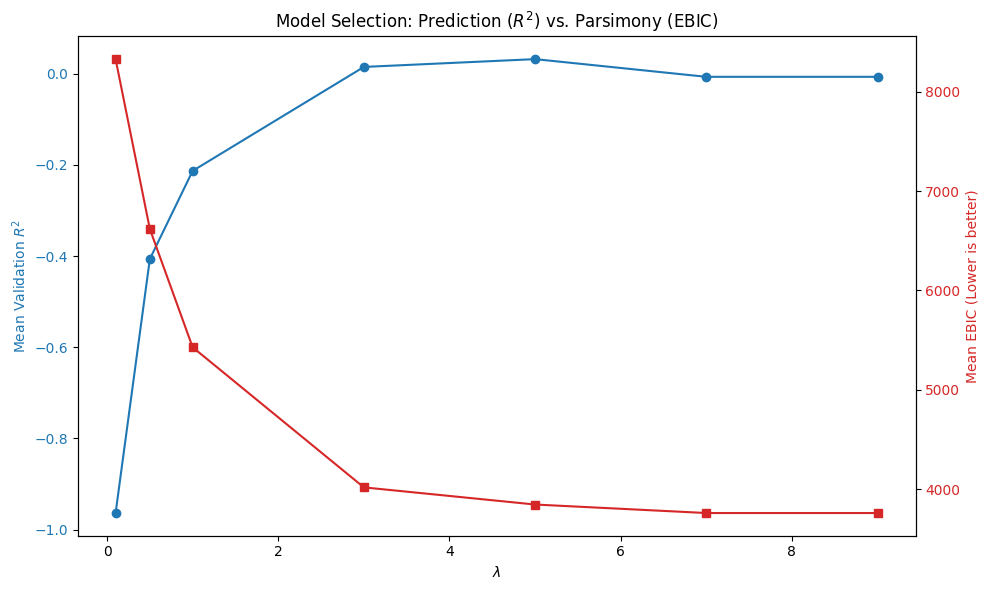

In [4]:
results_df = pd.DataFrame(results) # Assuming 'results' is the output of Parallel()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot R2 on the left axis
ax1.set_xlabel(r"$\lambda$")
ax1.set_ylabel("Mean Validation $R^2$", color="tab:blue")
ax1.plot(results_df["lambda"], results_df["mean_r2"], marker='o', color="tab:blue", label="$R^2$")
ax1.tick_params(axis='y', labelcolor="tab:blue")

# Plot EBIC on the right axis
ax2 = ax1.twinx()
ax2.set_ylabel("Mean EBIC (Lower is better)", color="tab:red")
ax2.plot(results_df["lambda"], results_df["mean_ebic"], marker='s', color="tab:red", label="EBIC")
ax2.tick_params(axis='y', labelcolor="tab:red")

plt.title("Model Selection: Prediction ($R^2$) vs. Parsimony (EBIC)")
fig.tight_layout()
plt.show()

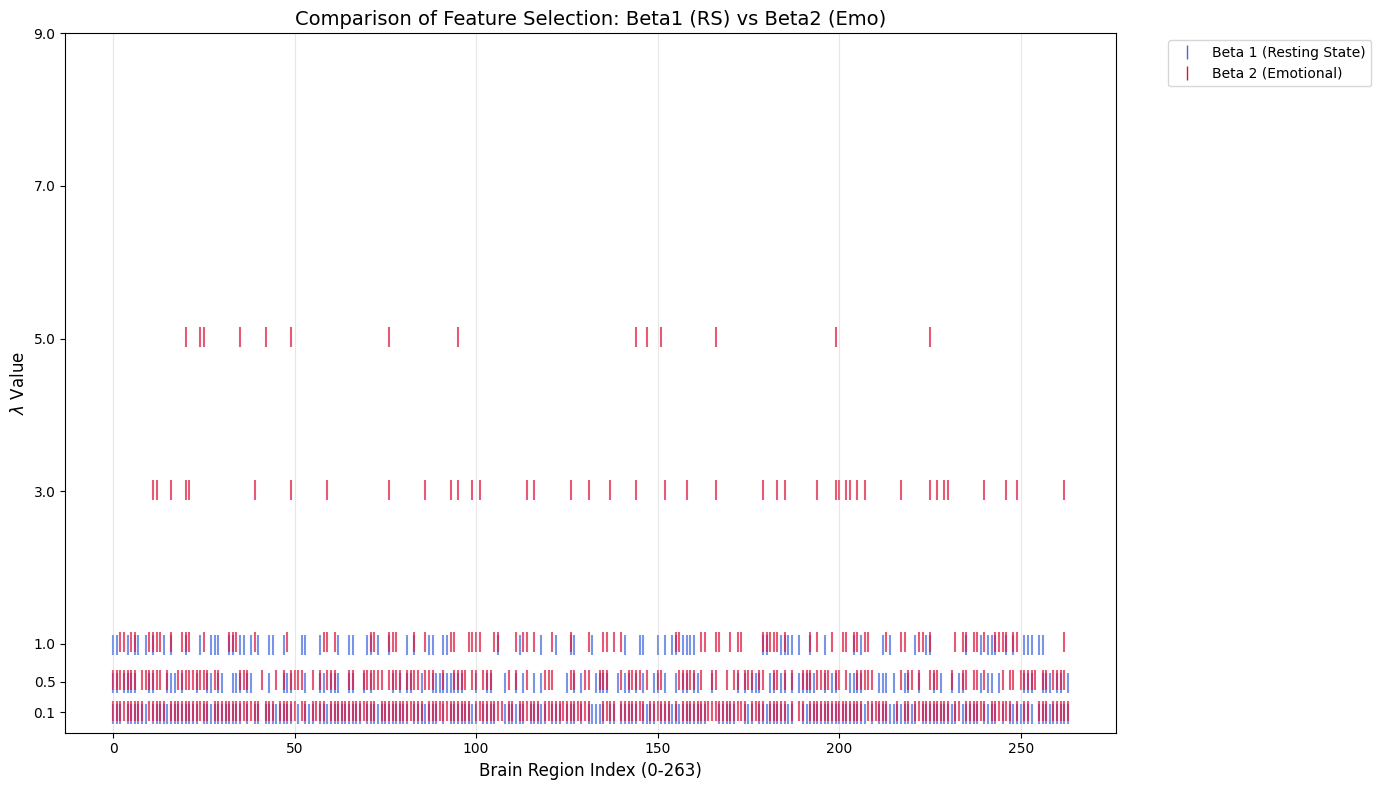

In [5]:
plt.figure(figsize=(14, 8))

for i, res in enumerate(results):
    lam = res["lambda"]
    # We'll take the first fold to represent the support for this lambda
    s1 = res["folds"][0]["supp1"]
    s2 = res["folds"][0]["supp2"]
    
    # Plot Beta 1 (Resting State)
    plt.scatter(s1, [lam - 0.02] * len(s1), color='royalblue', marker='|', 
                s=200, alpha=0.7, label=rf"$\beta_1$ (RS) for $\lambda$={lam}" if i == 0 else "")
    
    # Plot Beta 2 (Emotional) - Shifted slightly up so they don't overlap
    plt.scatter(s2, [lam + 0.02] * len(s2), color='crimson', marker='|', 
                s=200, alpha=0.7, label=rf"$\beta_2$ (Emo) for $\lambda$={lam}" if i == 0 else "")

plt.title("Comparison of Feature Selection: Beta1 (RS) vs Beta2 (Emo)", fontsize=14)
plt.xlabel("Brain Region Index (0-263)", fontsize=12)
plt.ylabel(r"$\lambda$ Value", fontsize=12)
plt.yticks(LAMBDA_GRID)

# Custom legend to simplify the view
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='royalblue', marker='|', linestyle='None', markersize=10, label='Beta 1 (Resting State)'),
                   Line2D([0], [0], color='crimson', marker='|', linestyle='None', markersize=10, label='Beta 2 (Emotional)')]
plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.25, 1))

plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

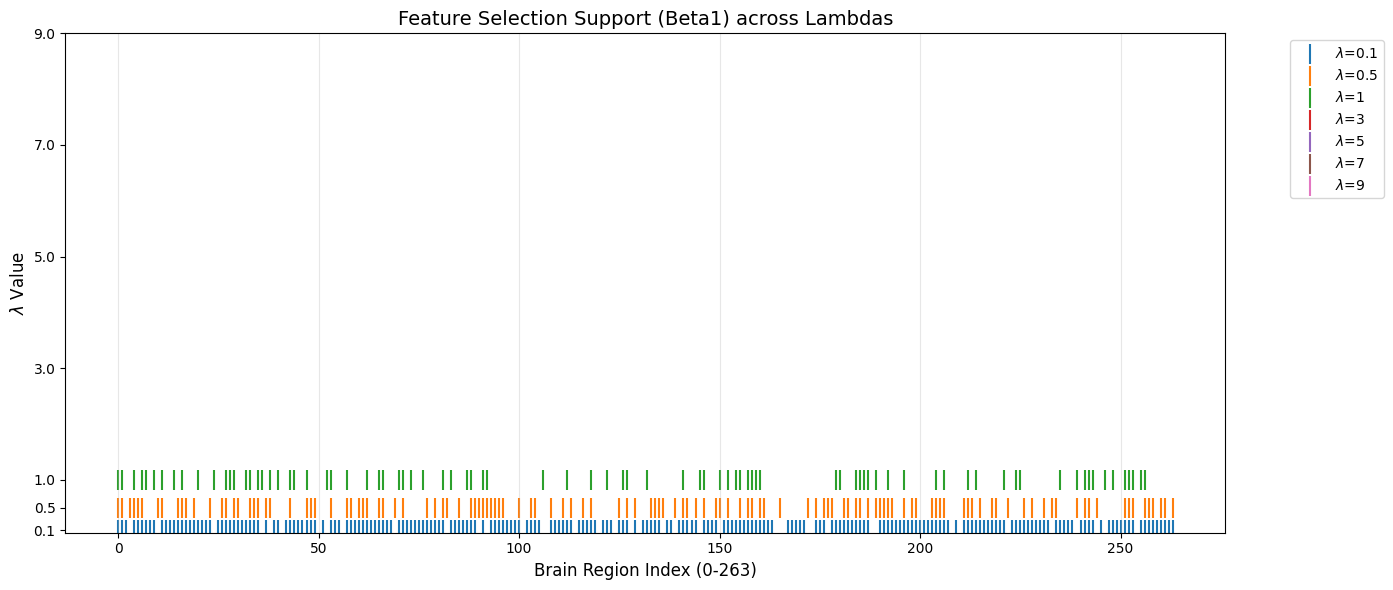

In [6]:
plt.figure(figsize=(14, 6))

for i, res in enumerate(results):
    # Taking support from the first fold of each lambda for comparison
    s1 = res["folds"][0]["supp1"]
    plt.scatter(s1, [res["lambda"]] * len(s1), marker='|', s=200, 
                label=rf"$\lambda$={res['lambda']}")

plt.title("Feature Selection Support (Beta1) across Lambdas", fontsize=14)
plt.xlabel("Brain Region Index (0-263)", fontsize=12)
plt.ylabel(r"$\lambda$ Value", fontsize=12)
plt.yticks(LAMBDA_GRID)
plt.grid(True, axis='x', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

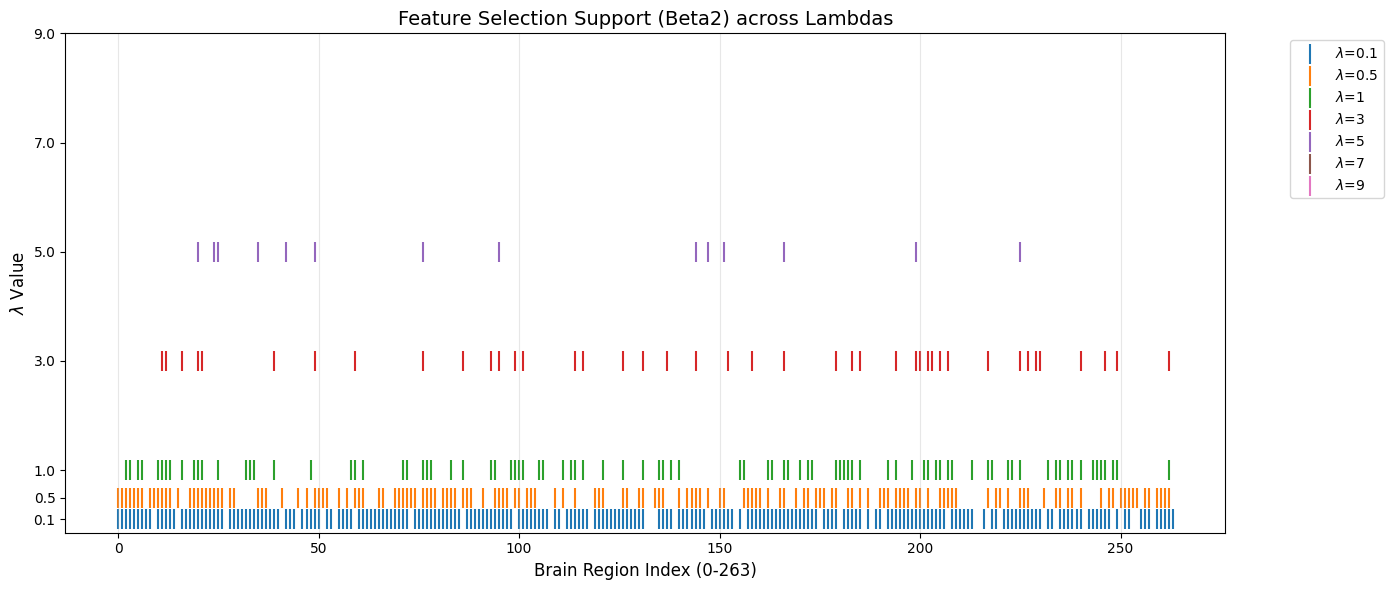

In [7]:
plt.figure(figsize=(14, 6))

for i, res in enumerate(results):
    # Taking support from the first fold of each lambda for comparison
    s1 = res["folds"][0]["supp2"]
    plt.scatter(s1, [res["lambda"]] * len(s1), marker='|', s=200, 
                label=rf"$\lambda$={res['lambda']}")

plt.title("Feature Selection Support (Beta2) across Lambdas", fontsize=14)
plt.xlabel("Brain Region Index (0-263)", fontsize=12)
plt.ylabel(r"$\lambda$ Value", fontsize=12)
plt.yticks(LAMBDA_GRID)
plt.grid(True, axis='x', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
best_lam = float(summary_df.iloc[0]["lambda"])
print(f"Fitting final model with best lambda: {best_lam}")

# Center full data for final run
X1_c = X1 - X1.mean(axis=2, keepdims=True)
X2_c = X2 - X2.mean(axis=2, keepdims=True)
y_c = y - y.mean()


Fitting final model with best lambda: 7.0
0 th try
initialized loss: 397.3865051269531


 40%|████      | 2418/6000 [02:55<04:19, 13.80it/s]


Job took:  175.21028804779053
Final loss: 392.4454650878906
1 th try
initialized loss: 390.98553466796875


 39%|███▉      | 2333/6000 [02:49<04:26, 13.74it/s]


Job took:  169.86524319648743
Final loss: 392.4382629394531
2 th try
initialized loss: 392.58270263671875


 35%|███▌      | 2114/6000 [02:33<04:42, 13.75it/s]


Job took:  153.71623301506042
Final loss: 392.4454040527344
Final loss: 392.4382629394531


In [14]:
best_lam = 2
final_model = bilinear_lasso(X1_c, X2_c, y_c, best_lam, best_lam)
final_model.initialize_beta(jnp.zeros((P, 1)), jnp.zeros((P, 1)))
final_model.fit(num_candidates=3, max_iter=MAX_ITER, step_size=STEP_SIZE, tol=TOL)

# Final stats
final_y_pred = predict_bilinear(X1_c, X2_c, final_model.beta1, final_model.beta2)
final_metrics = evaluate_prediction(y_c, final_y_pred)


0 th try
initialized loss: 388.8986511230469


100%|██████████| 6000/6000 [07:17<00:00, 13.73it/s]


Job took:  437.14668321609497
Final loss: 332.2259521484375
1 th try
initialized loss: 393.2984619140625


100%|██████████| 6000/6000 [07:48<00:00, 12.81it/s]


Job took:  468.56190490722656
Final loss: 327.7764587402344
2 th try
initialized loss: 390.16973876953125


100%|██████████| 6000/6000 [07:16<00:00, 13.73it/s]


Job took:  436.9278211593628
Final loss: 329.8321228027344
Final loss: 327.7764587402344


In [15]:
print(f"\nFinal Model R2 (Full Dataset): {final_metrics['r2']:.4f}")
print(f"Significant Features (Beta1): {len(np.where(np.abs(final_model.beta1) > 0.1)[0])}")


Final Model R2 (Full Dataset): 0.4029
Significant Features (Beta1): 41


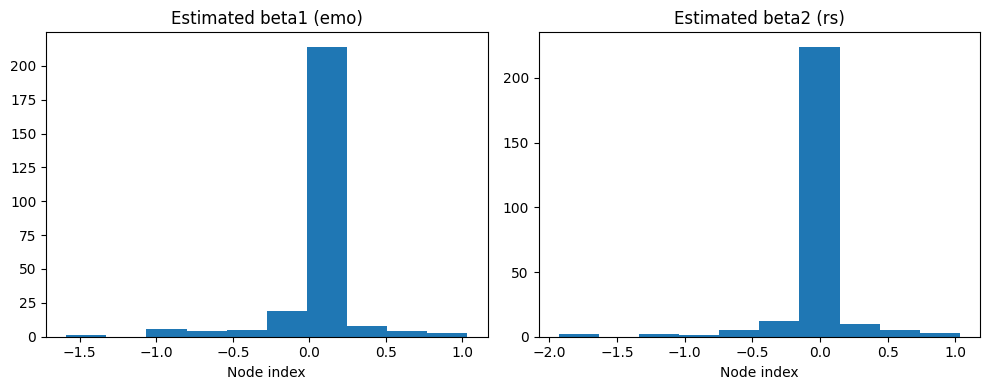

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
# axs[0].bar(range(len(model.beta1)), np.array(model.beta1).flatten())
axs[0].hist(np.array(final_model.beta1).flatten())
axs[0].set_title('Estimated beta1 (emo)')
axs[0].set_xlabel('Node index')
# axs[1].bar(range(len(model.beta2)), np.array(model.beta2).flatten())
axs[1].hist(np.array(final_model.beta2).flatten())
axs[1].set_title('Estimated beta2 (rs)')
axs[1].set_xlabel('Node index')
plt.tight_layout()
plt.show()

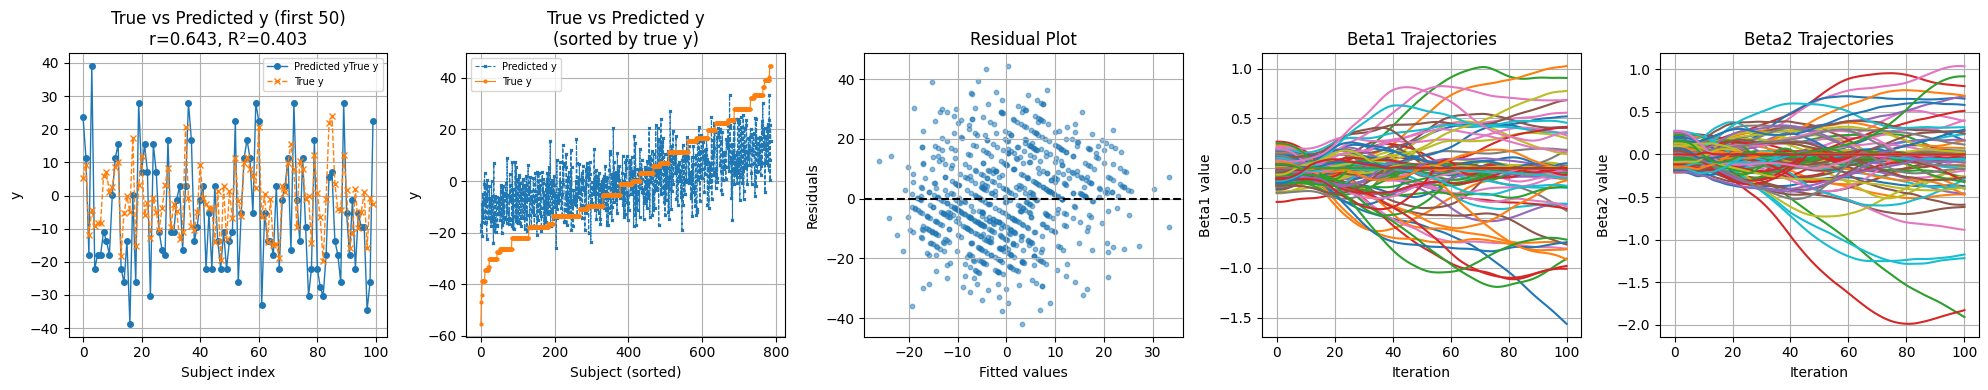

In [17]:
y_true = np.array(y_c)
y_hat = (np.einsum('ij,ijk,ji->k', final_model.beta1, np.array(X1_c), final_model.beta1) +
         np.einsum('ij,ijk,ji->k', final_model.beta2, np.array(X2_c), final_model.beta2))
residuals = y_true - y_hat

corr = np.corrcoef(y_true, y_hat)[0, 1]
r2   = 1 - np.var(residuals) / np.var(y_true)

beta1_traj = np.array(final_model.trajectory[final_model.sel_idx]['beta1'])  # (num_steps, p, 1)
beta2_traj = np.array(final_model.trajectory[final_model.sel_idx]['beta2'])  # (num_steps, p, 1)


plt.figure(figsize=(20, 4))

# Panel 1: First 50 subjects, line+dot style
plt.subplot(1, 5, 1)
plt.plot(y_true[:100], 'o-', markersize=4, linewidth=1, label='Predicted yTrue y')
plt.plot(y_hat[:100],  'x--', markersize=4, linewidth=1, label='True y')
plt.title(f'True vs Predicted y (first 50)\nr={corr:.3f}, R²={r2:.3f}')
plt.xlabel('Subject index')
plt.ylabel('y')
plt.legend(fontsize=7)
plt.grid(True)

# Panel 2: Sorted by true y — predicted first (behind), true on top
plt.subplot(1, 5, 2)
idx = np.argsort(y_true)
plt.plot(y_hat[idx],  'x--', markersize=2, linewidth=0.8, label='Predicted y')
plt.plot(y_true[idx], 'o-',  markersize=2, linewidth=0.8, label='True y')
plt.title('True vs Predicted y\n(sorted by true y)')
plt.xlabel('Subject (sorted)')
plt.ylabel('y')
plt.legend(fontsize=7)
plt.grid(True)

# Panel 3: Residual plot
plt.subplot(1, 5, 3)
plt.scatter(y_hat, residuals, s=10, alpha=0.5)
plt.axhline(0, linestyle='--', color='k')
plt.title('Residual Plot')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid(True)

# Panel 4: Beta1 trajectories (first 5 components)
plt.subplot(1, 5, 4)
for i in range(beta1_traj.shape[1]):
    plt.plot(beta1_traj[:, i, 0], label=f'beta1[{i}]')
plt.title('Beta1 Trajectories')
plt.xlabel('Iteration')
plt.ylabel('Beta1 value')
plt.grid(True)

# Panel 5: Beta2 trajectories (first 5 components)
plt.subplot(1, 5, 5)
for i in range(beta2_traj.shape[1]):
    plt.plot(beta2_traj[:, i], label=f'beta2[{i}]')
plt.title('Beta2 Trajectories')
plt.xlabel('Iteration')
plt.ylabel('Beta2 value')
plt.grid(True)

plt.tight_layout()
plt.show()

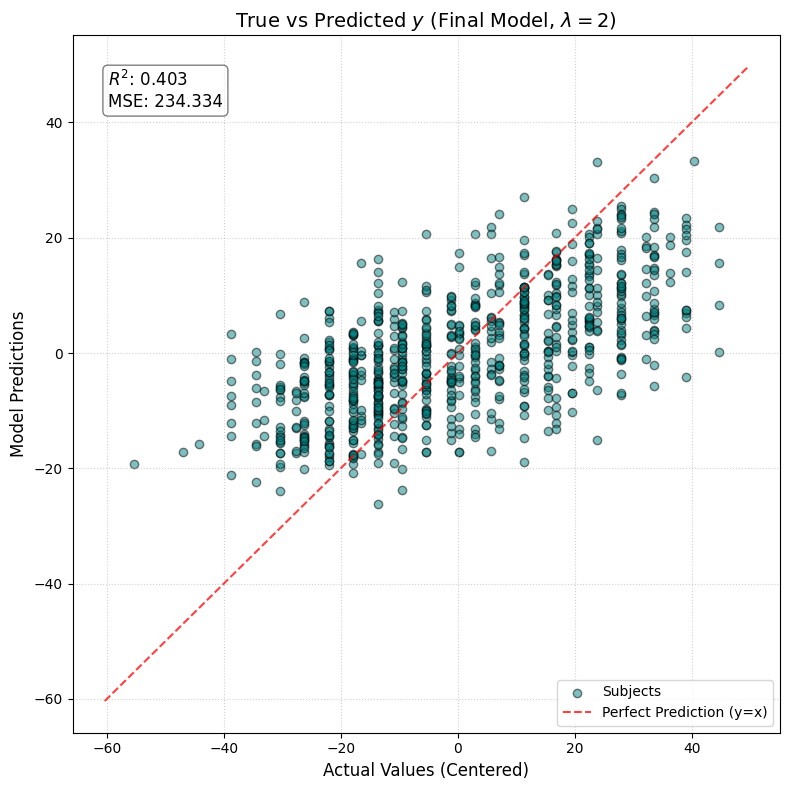

In [18]:
import matplotlib.pyplot as plt

def plot_regression_results(y_true, y_pred, lam_val):
    # Convert to numpy for plotting
    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    
    plt.figure(figsize=(8, 8))
    
    # 1. Scatter plot of points
    plt.scatter(y_true_np, y_pred_np, alpha=0.5, color='teal', edgecolors='k', label='Subjects')
    
    # 2. Add the 45-degree "Perfect Prediction" line
    # We find the min/max of both axes to ensure the line covers the whole plot
    lims = [
        np.min([plt.xlim(), plt.ylim()]),  # min of both axes
        np.max([plt.xlim(), plt.ylim()]),  # max of both axes
    ]
    plt.plot(lims, lims, 'r--', alpha=0.75, zorder=3, label='Perfect Prediction (y=x)')
    
    # 3. Formatting
    plt.title(rf"True vs Predicted $y$ (Final Model, $\lambda={lam_val}$)", fontsize=14)
    plt.xlabel("Actual Values (Centered)", fontsize=12)
    plt.ylabel("Model Predictions", fontsize=12)
    
    # Add a text box with metrics
    mse = np.mean((y_true_np - y_pred_np)**2)
    r2 = 1 - mse / np.var(y_true_np)
    stats_text = f"$R^2$: {r2:.3f}\nMSE: {mse:.3f}"
    plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
                   fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Execute the plot
# (Assuming final_y_pred and y_c come from your Final Model Fit cell)
plot_regression_results(y_c, final_y_pred, best_lam)

In [19]:
X1[:,:,0]

Array([[0.        , 1.1702881 , 0.7234536 , ..., 0.81617373, 0.66339827,
        0.5309873 ],
       [1.1702881 , 0.        , 0.5809368 , ..., 0.91559696, 0.6770624 ,
        0.49709845],
       [0.7234536 , 0.5809368 , 0.        , ..., 0.5272668 , 0.63788384,
        0.72128975],
       ...,
       [0.81617373, 0.91559696, 0.5272668 , ..., 0.        , 1.0475433 ,
        0.77799875],
       [0.66339827, 0.6770624 , 0.63788384, ..., 1.0475433 , 0.        ,
        0.94416934],
       [0.5309873 , 0.49709845, 0.72128975, ..., 0.77799875, 0.94416934,
        0.        ]], dtype=float32)

In [21]:
import os
import pandas as pd
import numpy as np

# 1. Setup the directory
save_dir = "/Users/xue6bq/Desktop/real_data/elbow"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# --- A. Save the Summary Table ---
# This is the small table (usually 10-20 rows) with your CV averages
summary_df.to_csv(os.path.join(save_dir, "simulation_summary.csv"), index=False)

# --- B. Save Ground Truth & Estimated Weights ---
# You still need these for the stem plots (the most important part of the viz)
# np.save(os.path.join(save_dir, "beta1_true.npy"), np.array(b1_true))
# np.save(os.path.join(save_dir, "beta2_true.npy"), np.array(b2_true))
np.save(os.path.join(save_dir, "beta1_estimated.npy"), np.array(final_model.beta1))
np.save(os.path.join(save_dir, "beta2_estimated.npy"), np.array(final_model.beta2))
np.save(os.path.join(save_dir, "y_true.npy"), np.array(y))

print(f"✅ Summary and weights exported to: {save_dir}")

✅ Summary and weights exported to: /Users/xue6bq/Desktop/real_data/elbow


In [39]:
import pandas as pd
import numpy as np
import os

# Define path
save_dir = "/Users/xue6bq/Desktop/real_data/elbow/"

# Load the data
summary_df = pd.read_csv(os.path.join(save_dir, "simulation_summary.csv"))
# b1_true = np.load(os.path.join(save_dir, "beta1_true.npy"))
# b2_true = np.load(os.path.join(save_dir, "beta2_true.npy"))
b1_est  = np.load(os.path.join(save_dir, "beta1_estimated.npy"))
b2_est  = np.load(os.path.join(save_dir, "beta2_estimated.npy"))
y_true  = np.load(os.path.join(save_dir, "y_true.npy"))

# Lightweight model wrapper
class ModelWrapper:
    def __init__(self, b1, b2):
        self.beta1 = b1
        self.beta2 = b2

loaded_model = ModelWrapper(b1_est, b2_est)

/var/folders/ds/hzlmym6914z94tg39pt41n280000gs/T/ipykernel_88856/3092193257.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


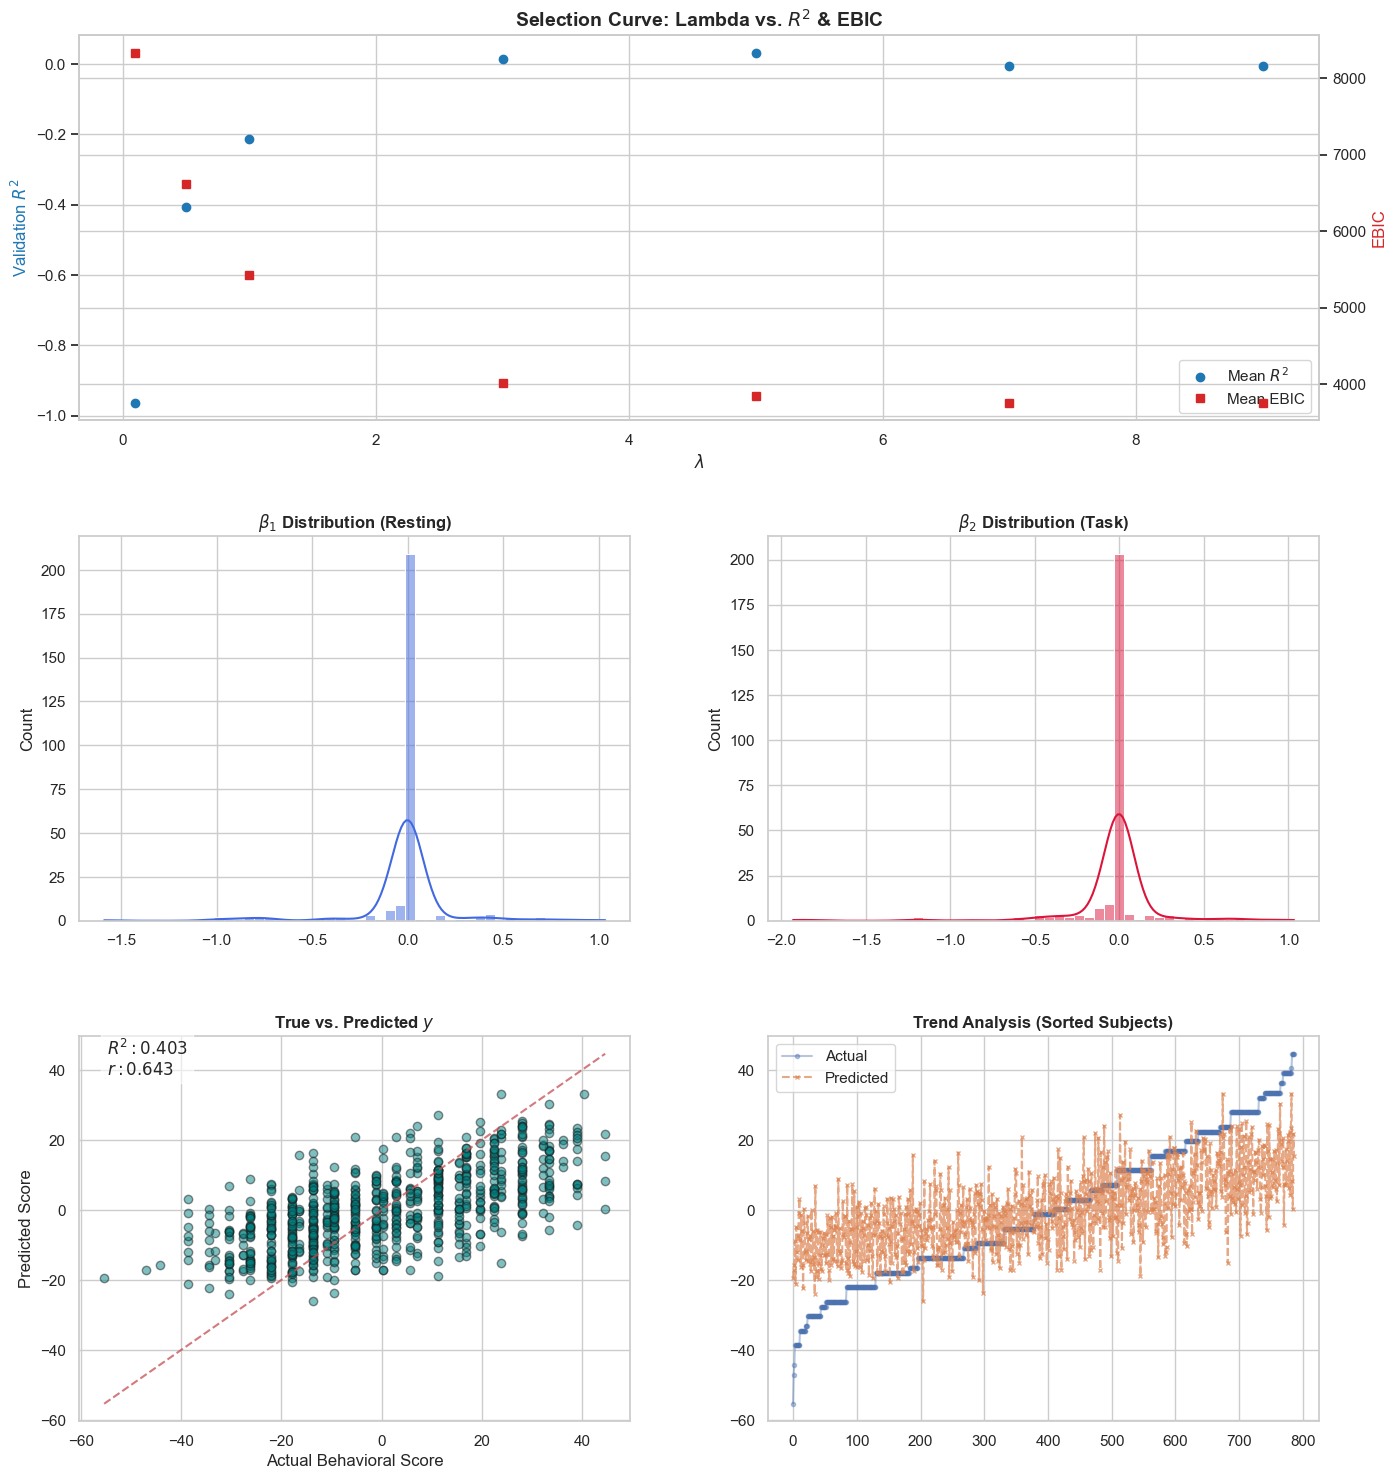

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_final_diagnostic_dashboard(results_df, b1_est, b2_est, X1, X2, y_true):
    sns.set_theme(style="whitegrid")
    
    # 1. Calculate Predicted Y
    # Flatten weights to ensure dot product matches dimensions
    est_b1 = np.array(b1_est).flatten()
    est_b2 = np.array(b2_est).flatten()
    
    # y_hat = diag(B1.T * X1 * B1) + diag(B2.T * X2 * B2)
    y_hat = (np.einsum('i,ijk,j->k', est_b1, X1, est_b1) + 
             np.einsum('i,ijk,j->k', est_b2, X2, est_b2))
    
    # 2. Setup Figure Layout (3 Rows)
    fig = plt.figure(figsize=(16, 18))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.25)
    
    # --- ROW 1: MODEL SELECTION ---
    ax1 = fig.add_subplot(gs[0, :])
    ax1_twin = ax1.twinx()
    lns1 = ax1.plot(results_df["lambda"], results_df["Test R2"], 'o', color="tab:blue", label="Mean $R^2$")
    lns2 = ax1_twin.plot(results_df["lambda"], results_df["EBIC"], 's', color="tab:red", label="Mean EBIC")
    ax1.set_xlabel(r"$\lambda$")
    ax1.set_ylabel("Validation $R^2$", color="tab:blue")
    ax1_twin.set_ylabel("EBIC", color="tab:red")
    ax1.set_title("Selection Curve: Lambda vs. $R^2$ & EBIC", fontweight='bold', fontsize=14)
    lns = lns1 + lns2
    ax1.legend(lns, [l.get_label() for l in lns], loc='lower right')

    # --- ROW 2: PARAMETER SPARSITY ---
    ax2 = fig.add_subplot(gs[1, 0])
    sns.histplot(est_b1, bins=50, kde=True, color='royalblue', ax=ax2)
    ax2.set_title(r"$\beta_1$ Distribution (Resting)", fontweight='bold')
    
    ax3 = fig.add_subplot(gs[1, 1])
    sns.histplot(est_b2, bins=50, kde=True, color='crimson', ax=ax3)
    ax3.set_title(r"$\beta_2$ Distribution (Task)", fontweight='bold')

    # --- ROW 3: PREDICTION QUALITY ---
    # 3.1 Scatter Plot with Identity Line
    ax4 = fig.add_subplot(gs[2, 0])
    ax4.scatter(y_true, y_hat, alpha=0.5, color='teal', edgecolors='k')
    lims = [min(y_true.min(), y_hat.min()), max(y_true.max(), y_hat.max())]
    ax4.plot(lims, lims, 'r--', alpha=0.75, label='Perfect Prediction')
    ax4.set_xlabel("Actual Behavioral Score")
    ax4.set_ylabel("Predicted Score")
    ax4.set_title("True vs. Predicted $y$", fontweight='bold')
    
    # Add Stats
    r2_val = 1 - np.mean((y_true - y_hat)**2) / np.var(y_true)
    corr = np.corrcoef(y_true, y_hat)[0, 1]
    ax4.text(0.05, 0.9, f"$R^2: {r2_val:.3f}$\n$r: {corr:.3f}$", transform=ax4.transAxes, 
             bbox=dict(facecolor='white', alpha=0.6))

    # 3.2 Sorted Comparison
    ax5 = fig.add_subplot(gs[2, 1])
    idx = np.argsort(y_true)
    ax5.plot(y_true[idx], 'o-', markersize=3, label='Actual', alpha=0.4)
    ax5.plot(y_hat[idx], 'x--', markersize=3, label='Predicted', alpha=0.7)
    ax5.set_title("Trend Analysis (Sorted Subjects)", fontweight='bold')
    ax5.legend()

    plt.tight_layout()
    plt.show()

# Execution:
plot_final_diagnostic_dashboard(summary_df, b1_est, b2_est, X1_c, X2_c, y_true-y_true.mean())

In [41]:
summary_df

,lambda,Test R2,Avg Features,EBIC,BIC,Stability,MSE Mean
0,7.0,-0.006987,0.0,3760.003076,3760.003076,0.033826,393.409192
1,9.0,-0.006987,0.0,3760.003076,3760.003076,0.033826,393.409192
2,5.0,0.031808,12.8,3845.544339,3765.299906,0.044235,378.127698
3,3.0,0.014673,35.0,4018.222665,3798.804295,0.044227,384.863159
4,1.0,-0.213296,178.6,5428.246921,4308.586325,0.111885,474.608435
5,0.5,-0.406603,291.6,6618.868285,4790.799808,0.129124,549.016907
6,0.1,-0.963680,435.2,8328.353692,5600.042989,0.076575,767.330908


<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/var/folders/ds/hzlmym6914z94tg39pt41n280000gs/T/ipykernel_88856/2710326234.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title("Model Selection: $\lambda$ Grid Search", fontweight='bold', fontsize=14)
/var/folders/ds/hzlmym6914z94tg39pt41n280000gs/T/ipykernel_88856/2710326234.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


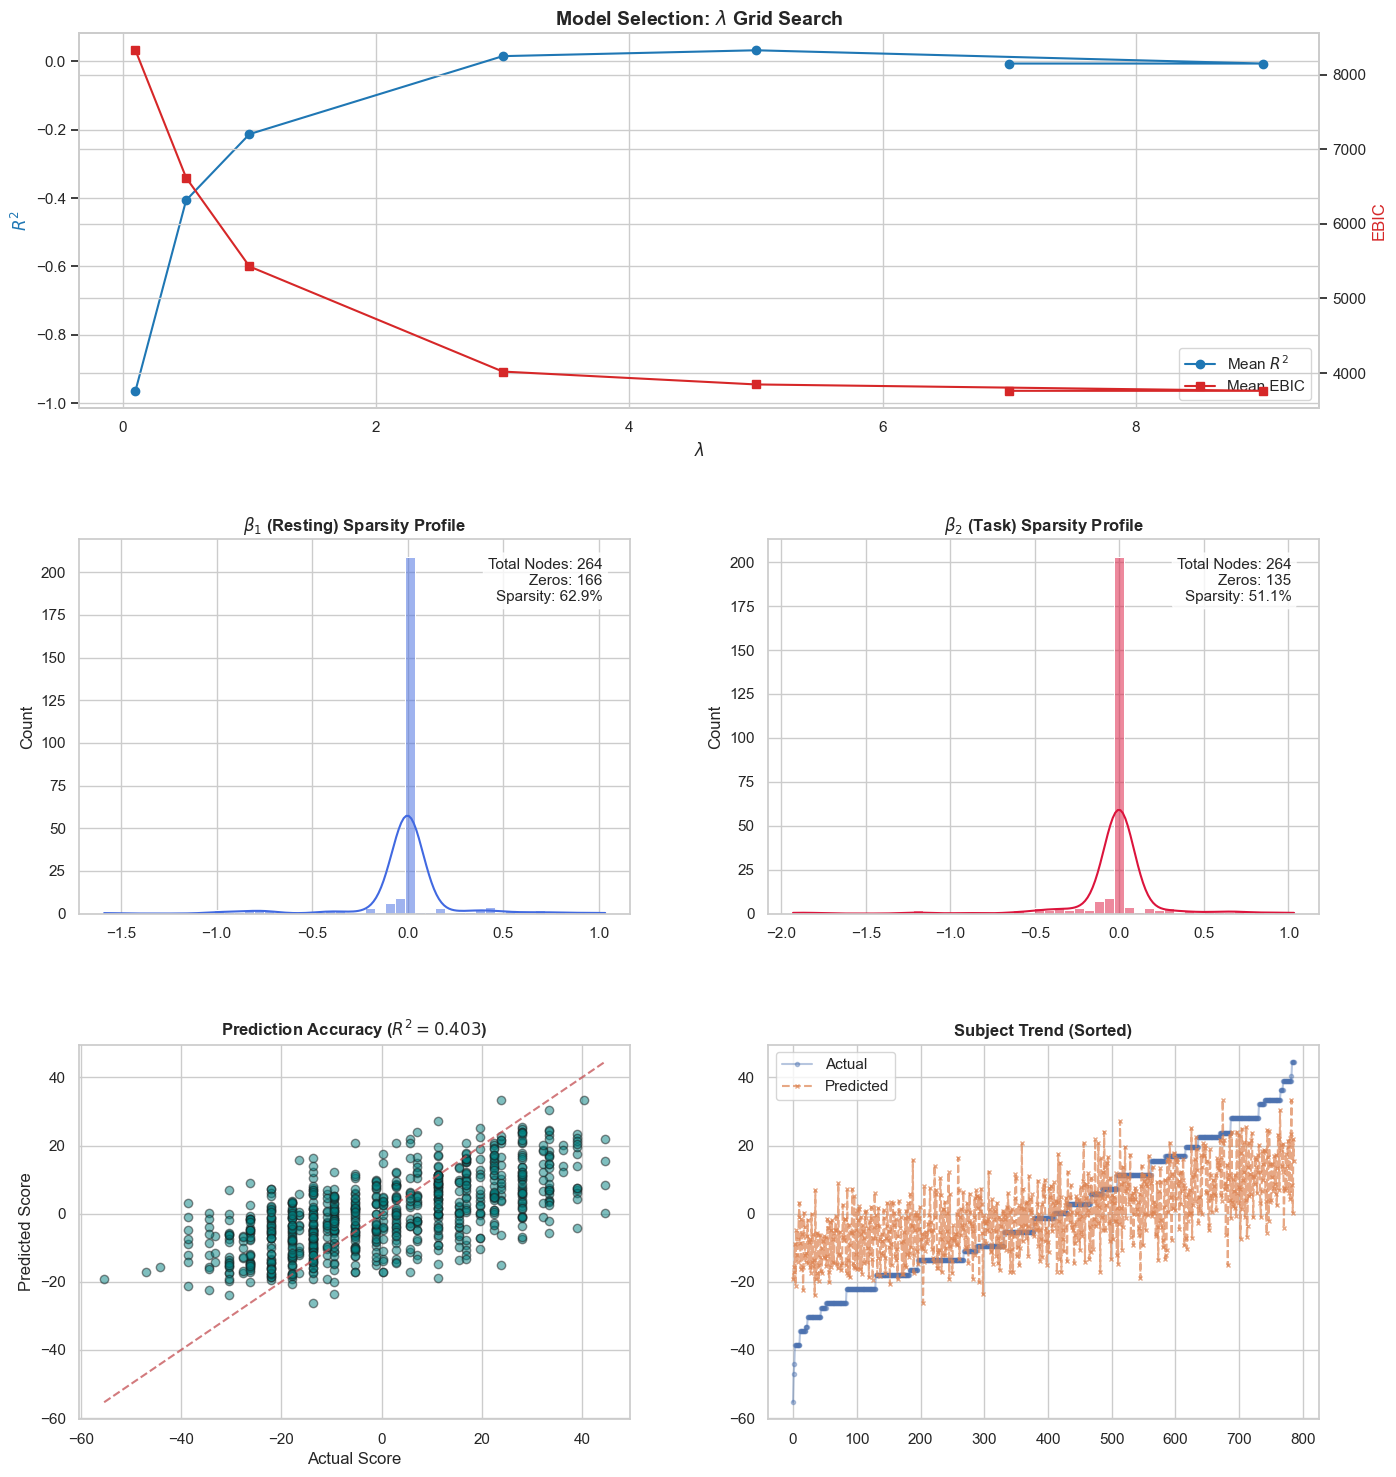

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_comprehensive_inference_report(results_df, b1_est, b2_est, X1, X2, y_true):
    sns.set_theme(style="whitegrid")
    
    # 1. Prediction Calculation
    est_b1 = np.array(b1_est).flatten()
    est_b2 = np.array(b2_est).flatten()
    y_hat = (np.einsum('i,ijk,j->k', est_b1, X1, est_b1) + 
             np.einsum('i,ijk,j->k', est_b2, X2, est_b2))
    
    # 2. Setup Figure (3 Rows)
    fig = plt.figure(figsize=(16, 18))
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.25)
    
    # --- ROW 1: SELECTION (Lambda vs R2/EBIC) ---
    ax1 = fig.add_subplot(gs[0, :])
    ax1_twin = ax1.twinx()
    ln1 = ax1.plot(results_df["lambda"], results_df["Test R2"], 'o-', color="tab:blue", label="Mean $R^2$")
    ln2 = ax1_twin.plot(results_df["lambda"], results_df["EBIC"], 's-', color="tab:red", label="Mean EBIC")
    ax1.set_title("Model Selection: $\lambda$ Grid Search", fontweight='bold', fontsize=14)
    ax1.set_xlabel(r"$\lambda$")
    ax1.set_ylabel("$R^2$", color="tab:blue")
    ax1_twin.set_ylabel("EBIC", color="tab:red")
    ax1.legend(ln1+ln2, [l.get_label() for l in ln1+ln2], loc='lower right')

    # --- ROW 2: SPARSITY (Histograms + Zero Counts) ---
    for i, (vals, title, color, col) in enumerate([
        (est_b1, r"$\beta_1$ (Resting)", "royalblue", 0),
        (est_b2, r"$\beta_2$ (Task)", "crimson", 1)
    ]):
        ax = fig.add_subplot(gs[1, col])
        sns.histplot(vals, bins=50, kde=True, color=color, ax=ax)
        
        # Sparsity Calculation (using a small tolerance for float precision)
        n_zeros = np.sum(np.abs(vals) < 1e-6)
        p_zeros = (n_zeros / len(vals)) * 100
        
        stats_text = f"Total Nodes: {len(vals)}\nZeros: {n_zeros}\nSparsity: {p_zeros:.1f}%"
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                va='top', ha='right', fontsize=11,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_title(f"{title} Sparsity Profile", fontweight='bold')

    # --- ROW 3: PREDICTION QUALITY ---
    # Left: Regression Scatter
    ax4 = fig.add_subplot(gs[2, 0])
    ax4.scatter(y_true, y_hat, alpha=0.5, color='teal', edgecolors='k')
    lims = [min(y_true.min(), y_hat.min()), max(y_true.max(), y_hat.max())]
    ax4.plot(lims, lims, 'r--', alpha=0.75, label='Perfect Prediction')
    
    r2_final = 1 - np.mean((y_true - y_hat)**2) / np.var(y_true)
    ax4.set_title(f"Prediction Accuracy ($R^2 = {r2_final:.3f}$)", fontweight='bold')
    ax4.set_xlabel("Actual Score")
    ax4.set_ylabel("Predicted Score")

    # Right: Sorted Trends
    ax5 = fig.add_subplot(gs[2, 1])
    idx = np.argsort(y_true)
    ax5.plot(y_true[idx], 'o-', markersize=3, label='Actual', alpha=0.4)
    ax5.plot(y_hat[idx], 'x--', markersize=3, label='Predicted', alpha=0.7)
    ax5.set_title("Subject Trend (Sorted)", fontweight='bold')
    ax5.legend()

    plt.tight_layout()
    plt.show()

# To use:
plot_comprehensive_inference_report(summary_df, b1_est, b2_est, X1_c, X2_c, y_true-y_true.mean())